# 04 - Validity and Error Analysis

Notebooks 02 and 03 got near-perfect scores. This notebook asks the
follow-up questions those scores raise:

1. **Base rates**: our test set is 42% phishing, but real traffic is
   maybe 1-in-1,000 or worse. What happens to precision at realistic
   prevalence?
2. **Statistics**: with this few errors, are the differences between
   models even meaningful? (bootstrap intervals + McNemar's test)
3. **The open question from notebook 02**: the engineered features
   failed with content features present. Do they help in the harder
   URL-only setting?
4. **Error analysis**: what do the URLs the models still miss look
   like?

Uses the same dedupe + domain-grouped split as notebooks 02/03 so all
numbers are comparable.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rapidfuzz.distance import Levenshtein
from scipy.stats import binomtest
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBClassifier

manifest = json.loads(Path("../data/feature_columns.json").read_text())
clean = manifest["clean_numeric_features"]

df = pd.read_csv("../data/phiusiil.csv")
model_df = df.drop_duplicates(subset="URL").reset_index(drop=True)
y = model_df["label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr, te = next(gss.split(model_df, y, groups=model_df["Domain"]))
y_te = y.iloc[te].values
print(f"train {len(tr):,} / test {len(te):,}")

train 188,738 / test 46,632


## The two regimes, rebuilt

Same XGBoost settings as notebook 02 (the tuned parameters equal the
defaults). "Full" = the 49 clean features. "URL-only" = just the 21
features computable from the URL string itself, nothing that needs
fetching the page - the pre-click deployment setting.

In [2]:
URL_COLS = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
]


def fit_eval(X, name):
    """Train notebook-02-style XGBoost, return preds + confusion."""
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr = y.iloc[tr]
    m = XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    )
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)
    is_phish = pred == 0
    was_phish = y_te == 0
    tp = int((is_phish & was_phish).sum())
    fp = int((is_phish & ~was_phish).sum())
    fn = int((~is_phish & was_phish).sum())
    tn = int((~is_phish & ~was_phish).sum())
    acc = (tp + tn) / len(y_te)
    print(
        f"{name:28s} acc={acc:.4f}  FP={fp:3d}  FN={fn:3d}  "
        f"prec={tp / (tp + fp):.4f}  rec={tp / (tp + fn):.4f}"
    )
    return m, pred, (tp, fp, fn, tn)


m_full, p_full, cm_full = fit_eval(model_df[clean], "full clean (49)")
m_url, p_url, cm_url = fit_eval(model_df[URL_COLS], "URL-only (21)")

full clean (49)              acc=1.0000  FP=  0  FN=  2  prec=1.0000  rec=0.9999


URL-only (21)                acc=0.9981  FP= 12  FN= 78  prec=0.9994  rec=0.9960


(Precision/recall here treat **phishing as the positive class**, since
that's the thing we're trying to catch.)

The full model makes 2 errors in 46,632. The URL-only model makes 90.
Both look great - keep those two numbers in mind for the base-rate
section.

## Do the engineered features help in the URL-only setting?

Notebook 02 found entropy / brand-distance / punycode / shortener
features useless next to the content features, and left open whether
they'd matter when *only* the URL is available. Recompute them and
find out.

In [3]:
def entropy(s):
    counts = pd.Series(list(s)).value_counts(normalize=True)
    return float(-(counts * np.log2(counts)).sum())


BRANDS = [
    "google",
    "facebook",
    "youtube",
    "amazon",
    "apple",
    "microsoft",
    "paypal",
    "netflix",
    "instagram",
    "whatsapp",
    "linkedin",
    "twitter",
    "ebay",
    "chase",
    "wellsfargo",
    "bankofamerica",
    "citibank",
    "hsbc",
    "americanexpress",
    "dropbox",
    "adobe",
    "yahoo",
    "outlook",
    "office",
    "icloud",
    "steam",
    "spotify",
    "coinbase",
    "binance",
    "walmart",
    "usps",
    "fedex",
    "dhl",
    "irs",
    "att",
    "verizon",
]
SHORTENERS = {
    "bit.ly",
    "tinyurl.com",
    "goo.gl",
    "t.co",
    "ow.ly",
    "is.gd",
    "buff.ly",
    "cutt.ly",
    "rb.gy",
    "shorturl.at",
}


def sld(domain):
    """second-level label: mail.foo.com -> foo"""
    parts = domain.lower().removeprefix("www.").split(".")
    return parts[-2] if len(parts) >= 2 else parts[0]


def brand_dist(domain):
    s = sld(domain)
    return min(Levenshtein.normalized_distance(s, b) for b in BRANDS)


eng = pd.DataFrame(index=model_df.index)
eng["url_entropy"] = model_df["URL"].str.lower().map(entropy)
eng["domain_entropy"] = model_df["Domain"].str.lower().map(entropy)
eng["brand_distance"] = model_df["Domain"].map(brand_dist)
eng["is_punycode"] = (
    model_df["Domain"].str.lower().str.contains("xn--").astype(int)
)
host = model_df["Domain"].str.lower().str.removeprefix("www.")
eng["is_shortener"] = host.isin(SHORTENERS).astype(int)

m_urlp, p_urlp, cm_urlp = fit_eval(
    pd.concat([model_df[URL_COLS], eng], axis=1),
    "URL-only + engineered (26)",
)
m_nh, p_nh, cm_nh = fit_eval(
    model_df[[c for c in URL_COLS if c != "IsHTTPS"]],
    "URL-only, no IsHTTPS (20)",
)

imp = pd.Series(
    m_urlp.feature_importances_, index=URL_COLS + list(eng.columns)
)
ranks = imp.rank(ascending=False).astype(int)
print("\nengineered feature importance ranks (out of 26):")
print(ranks[eng.columns].to_string())

URL-only + engineered (26)   acc=0.9980  FP= 10  FN= 83  prec=0.9995  rec=0.9958


URL-only, no IsHTTPS (20)    acc=0.9977  FP= 23  FN= 86  prec=0.9988  rec=0.9956

engineered feature importance ranks (out of 26):
url_entropy       16
domain_entropy    17
brand_distance    14
is_punycode       22
is_shortener      22


**The answer is no, again.** Adding the engineered features leaves
accuracy basically unchanged (0.9981 vs 0.9980 - if anything one
false negative more), and their importance ranks sit at 14-22 out of
26. That closes the question notebook 02 left open: these features
don't earn their keep in either regime. (We keep this as an explicit
negative result for the report.)

Also worth noting: dropping `IsHTTPS` - the collection artifact -
only costs ~0.0004 accuracy, so the URL-only result doesn't secretly
lean on it.

## Are the model differences statistically real?

Two checks: a bootstrap confidence interval for each accuracy, and
McNemar's test on the paired predictions (the right test when two
models are evaluated on the same test set).

In [4]:
rng = np.random.default_rng(42)


def boot_ci(err, n_boot=2000):
    idx = rng.integers(0, len(err), size=(n_boot, len(err)))
    accs = 1 - err[idx].mean(axis=1)
    return np.percentile(accs, [2.5, 97.5])


err_full = (p_full != y_te).astype(int)
err_url = (p_url != y_te).astype(int)

lo, hi = boot_ci(err_full)
print(f"full model acc:     {1 - err_full.mean():.5f} [{lo:.5f}, {hi:.5f}]")
lo, hi = boot_ci(err_url)
print(f"URL-only model acc: {1 - err_url.mean():.5f} [{lo:.5f}, {hi:.5f}]")

only_url = int(((err_full == 0) & (err_url == 1)).sum())
only_full = int(((err_full == 1) & (err_url == 0)).sum())
p_val = binomtest(min(only_url, only_full), only_url + only_full).pvalue
print(
    f"\nMcNemar: URL-only-errors={only_url}, "
    f"full-only-errors={only_full}, p={p_val:.2e}"
)

full model acc:     0.99996 [0.99989, 1.00000]


URL-only model acc: 0.99807 [0.99764, 0.99846]

McNemar: URL-only-errors=90, full-only-errors=2, p=1.73e-24


The confidence intervals don't overlap and McNemar's test is
decisive (p ~ 1e-24): the full model really is better than the
URL-only model on *this test set*. That's worth stating because with
2-vs-90 errors it would be easy to wave hands; now it's tested.

## The base-rate problem: what do these numbers mean in the real world?

Our test set is 42% phishing. Real traffic is nothing like that - a
mail gateway or browser sees maybe 1 phishing URL per 1,000-10,000.
Precision at deployment depends on prevalence:

precision(p) = p*TPR / (p*TPR + (1-p)*FPR)

TPR and FPR come from our confusion matrices. One subtlety: the full
model had **zero** observed false positives, which makes its FPR look
like exactly 0. Zero observed events doesn't mean zero rate - the
"rule of three" gives a 95% upper bound of 3/n for an event never seen
in n trials, so we also plot a pessimistic curve using FPR <= 3/26,923.

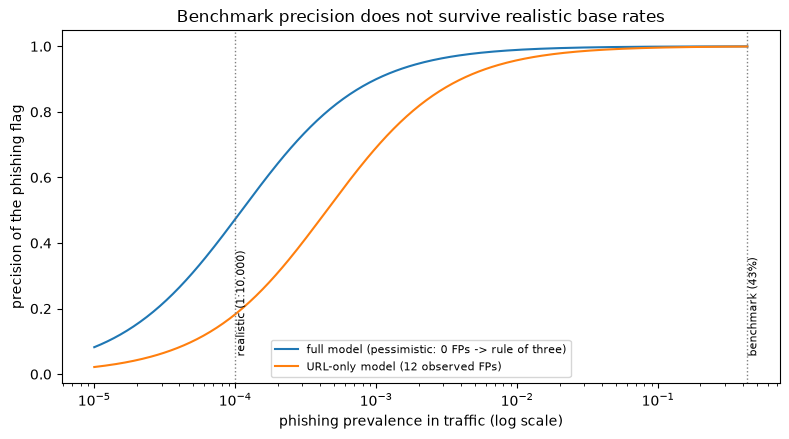

precision at selected prevalences:
  prevalence    0.43: full(pessimistic)=1.000  URL-only=0.999
  prevalence    0.01: full(pessimistic)=0.989  URL-only=0.958
  prevalence   0.001: full(pessimistic)=0.900  URL-only=0.691
  prevalence  0.0001: full(pessimistic)=0.473  URL-only=0.183


In [5]:
def rates(cm):
    tp, fp, fn, tn = cm
    return tp / (tp + fn), fp / (fp + tn), tn + fp


tpr_f, fpr_f, n_leg = rates(cm_full)
tpr_u, fpr_u, _ = rates(cm_url)
fpr_f_up = 3 / n_leg if fpr_f == 0 else fpr_f

pis = np.logspace(-5, np.log10(0.43), 300)


def prec_curve(tpr, fpr):
    return np.where(fpr == 0, 1.0, pis * tpr / (pis * tpr + (1 - pis) * fpr))


plt.figure(figsize=(8, 4.5))
plt.plot(
    pis,
    prec_curve(tpr_f, fpr_f_up),
    color="tab:blue",
    label="full model (pessimistic: 0 FPs -> rule of three)",
)
plt.plot(
    pis,
    prec_curve(tpr_u, fpr_u),
    color="tab:orange",
    label="URL-only model (12 observed FPs)",
)
plt.axvline(0.43, color="gray", linestyle=":", linewidth=1)
plt.text(0.43, 0.05, " benchmark (43%)", fontsize=8, rotation=90)
plt.axvline(1e-4, color="gray", linestyle=":", linewidth=1)
plt.text(1e-4, 0.05, " realistic (1:10,000)", fontsize=8, rotation=90)
plt.xscale("log")
plt.xlabel("phishing prevalence in traffic (log scale)")
plt.ylabel("precision of the phishing flag")
plt.title("Benchmark precision does not survive realistic base rates")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("precision at selected prevalences:")
for pi in (0.43, 1e-2, 1e-3, 1e-4):
    pf = pi * tpr_f / (pi * tpr_f + (1 - pi) * fpr_f_up)
    pu = pi * tpr_u / (pi * tpr_u + (1 - pi) * fpr_u)
    print(
        f"  prevalence {pi:>7}: full(pessimistic)={pf:.3f}  URL-only={pu:.3f}"
    )

This is the single most important chart for the report's discussion
section:

- The **URL-only model** - 99.81% accurate on the benchmark - has
  precision **~18% at 1:10,000** prevalence. Five out of six warnings
  would be false alarms.
- Even the **full model with zero observed false positives** can only
  be *proven* (95% confidence) to have precision >= ~47% at 1:10,000.
  Our test set is simply too small to certify performance at realistic
  base rates.

Benchmark accuracy is a property of the benchmark. Any deployment
claim needs orders of magnitude more legitimate-URL testing.

## Error analysis: what still gets missed?

Look at the 78 phishing URLs the URL-only model missed.

In [6]:
te_df = model_df.iloc[te]
missed = te_df[(p_url == 1) & (y_te == 0)]
caught = te_df[(p_url == 0) & (y_te == 0)]

prof = [
    "IsHTTPS",
    "TLDLegitimateProb",
    "URLLength",
    "SpacialCharRatioInURL",
    "NoOfDegitsInURL",
]
print(f"missed phishing URLs: {len(missed)}")
print("\nmedians, missed vs caught phishing:")
print(
    pd.DataFrame(
        {"missed": missed[prof].median(), "caught": caught[prof].median()}
    ).round(3)
)
print("\nexamples of missed URLs:")
for u in missed["URL"].head(10):
    print("  " + u[:90])

missed phishing URLs: 78

medians, missed vs caught phishing:
                       missed  caught
IsHTTPS                 1.000   0.000
TLDLegitimateProb       0.523   0.018
URLLength              29.000  33.000
SpacialCharRatioInURL   0.042   0.080
NoOfDegitsInURL         0.000   0.000

examples of missed URLs:
  https://www.support-lcioud-maps.info
  https://www.wsec06empresagalicioffice.com
  https://www.sharestion.com
  https://www.tomarchiobibite.it
  https://www.tenxstack.com/
  https://www.bendigo-verification.com
  https://www.ron-supp.pages.dev
  https://www.coinbesaprime-logi.com
  https://www.alullanos.com
  https://www.somahe-sarl.com


The pattern is clear and a little worrying: the URLs that get missed
are the **well-crafted** ones - HTTPS (median `IsHTTPS` 1 vs 0 for
caught), reputable TLDs (median `TLDLegitimateProb` 0.52 vs 0.02),
short, clean strings. The examples are classic brand impersonations:
`support-lcioud-maps.info` (iCloud with l/i swapped),
`coinbesaprime-logi.com` (Coinbase), `bendigo-verification.com` (a
bank). The model catches the sloppy phish and misses exactly the
dangerous ones.

Ironically these are the URLs our `brand_distance` feature was
designed for - and it still didn't help, because whole-word edit
distance fails on compound domains like `coinbesaprime-logi`
("coinbase" is *inside* the string, not near it in edit distance).
A token- or substring-based brand match is the obvious future-work
fix, and this error analysis is the evidence for why it should work.

## Does any of this transfer to a different dataset?

Everything so far - even the base-rate math - still uses PhiUSIIL's
own test set. The real question: does a model trained on PhiUSIIL work
on phishing data collected by someone else?

Test corpus: the **Sahingoz et al. (2019)** URL dataset (the same
paper we compare against in notebook 03) - 73,575 real URLs, both
classes, published on the authors' GitHub. After dedupe and dropping
~200 entries with no scheme, 54,681 usable URLs (29,910 legitimate /
24,771 phishing).

To make the test fair we do **not** use PhiUSIIL's provided columns.
We recompute ~20 lexical features with our own code, identically, from
the raw URL text of *both* datasets. `IsHTTPS` is deliberately left
out (notebook 01 showed it's a collection artifact). Train on the same
PhiUSIIL train split, sanity-check on the PhiUSIIL test split, then
predict on the external corpus with no retraining.

In [7]:
import urllib.request
from collections import Counter
from urllib.parse import urlsplit

EXT_DIR = Path("../data/external")
EXT_DIR.mkdir(exist_ok=True)
BASE = "https://raw.githubusercontent.com/ebubekirbbr/pdd/master/input/"
for fname in ("data_legitimate_36400.json", "data_phishing_37175.json"):
    if not (EXT_DIR / fname).exists():
        print("downloading", fname)
        urllib.request.urlretrieve(BASE + fname, EXT_DIR / fname)

TLD_PROB = df.groupby("TLD")["TLDLegitimateProb"].first().to_dict()
IP_RE = re.compile(r"^\d{1,3}(\.\d{1,3}){3}$")


def str_entropy(s):
    if not s:
        return 0.0
    n = len(s)
    return -sum(c / n * np.log2(c / n) for c in Counter(s).values())


def featurize(url):
    """~20 lexical features computed from the raw URL text only."""
    u = url.strip().lower()
    if "://" not in u:
        return None
    parts = urlsplit(u)
    hostname = parts.netloc.split("@")[-1].split(":")[0]
    if not hostname:
        return None
    rest = parts.path + ("?" + parts.query if parts.query else "")
    labels = hostname.split(".")
    sld_ = labels[-2] if len(labels) >= 2 else labels[0]
    tld = labels[-1]
    n = len(u)
    letters = sum(c.isalpha() for c in u)
    digits = sum(c.isdigit() for c in u)
    return {
        "url_len": n,
        "host_len": len(hostname),
        "path_len": len(rest),
        "n_host_labels": len(labels),
        "tld_len": len(tld),
        "tld_legit_prob": TLD_PROB.get(tld, 0.0),
        "is_ip": int(bool(IP_RE.match(hostname))),
        "n_hyphens_host": hostname.count("-"),
        "letter_ratio": letters / n,
        "digit_ratio": digits / n,
        "special_ratio": (n - letters - digits) / n,
        "digits_in_host": sum(c.isdigit() for c in hostname),
        "n_equals": u.count("="),
        "n_qmark": u.count("?"),
        "n_amp": u.count("&"),
        "n_pct": u.count("%"),
        "url_entropy": str_entropy(u),
        "host_entropy": str_entropy(hostname),
        "brand_edit": min(
            Levenshtein.normalized_distance(sld_, b) for b in BRANDS
        ),
        "brand_substr": int(
            any(b in hostname for b in BRANDS) and sld_ not in BRANDS
        ),
    }


F_phi = pd.DataFrame([featurize(u) for u in model_df["URL"]])

ext_leg = json.loads((EXT_DIR / "data_legitimate_36400.json").read_text())
ext_phi = json.loads((EXT_DIR / "data_phishing_37175.json").read_text())
rows, ext_labels, seen = [], [], set()
for urls, lab in ((ext_leg, 1), (ext_phi, 0)):
    for u in urls:
        if u in seen:
            continue
        seen.add(u)
        f = featurize(u)
        if f is not None:
            rows.append(f)
            ext_labels.append(lab)
F_ext = pd.DataFrame(rows)
y_ext = np.array(ext_labels)
print(
    f"external usable: {len(F_ext):,} "
    f"(legit {(y_ext == 1).sum():,} / "
    f"phish {(y_ext == 0).sum():,})"
)

external usable: 54,681 (legit 29,910 / phish 24,771)


In [8]:
def fit_transfer(cols, name):
    m = XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y.iloc[tr] == 0).sum() / (y.iloc[tr] == 1).sum(),
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    )
    m.fit(F_phi.iloc[tr][cols], y.iloc[tr])

    def rep(pred, truth, where):
        is_p, was_p = pred == 0, truth == 0
        tp = int((is_p & was_p).sum())
        fp = int((is_p & ~was_p).sum())
        fn = int((~is_p & was_p).sum())
        tn = int((~is_p & ~was_p).sum())
        acc = (tp + tn) / len(truth)
        print(
            f"  {where:22s} acc={acc:.4f} "
            f"prec={tp / max(tp + fp, 1):.4f} "
            f"rec={tp / max(tp + fn, 1):.4f}  FP={fp} FN={fn}"
        )
        return (tp, fp, fn, tn)

    print(name)
    rep(m.predict(F_phi.iloc[te][cols]), y.iloc[te].values, "PhiUSIIL test")
    ext_cm = rep(m.predict(F_ext[cols]), y_ext, "Sahingoz external")
    return m, ext_cm


ALL_LEX = list(F_phi.columns)
m_lex, ext_cm_lex = fit_transfer(ALL_LEX, "full lexical (20 feats):")
imp_lex = pd.Series(m_lex.feature_importances_, index=ALL_LEX)
print("\ntop importances:", imp_lex.nlargest(4).round(3).to_dict())
print(
    "median path_len - PhiUSIIL legit:",
    float(F_phi["path_len"][y.values == 1].median()),
    "| PhiUSIIL phish:",
    float(F_phi["path_len"][y.values == 0].median()),
    "| external legit:",
    float(F_ext["path_len"][y_ext == 1].median()),
)

full lexical (20 feats):
  PhiUSIIL test          acc=0.9970 prec=0.9989 rec=0.9939  FP=21 FN=120
  Sahingoz external      acc=0.4530 prec=0.4530 rec=1.0000  FP=29910 FN=1

top importances: {'path_len': 0.7590000033378601, 'url_len': 0.04500000178813934, 'digit_ratio': 0.03999999910593033, 'host_len': 0.03799999877810478}
median path_len - PhiUSIIL legit: 0.0 | PhiUSIIL phish: 1.0 | external legit: 29.0


**The benchmark model does not survive contact with other data.**
On PhiUSIIL's own test split the lexical model gets 99.7%. On the
Sahingoz corpus it collapses to **45.3% - worse than guessing** -
because it flags essentially every legitimate URL as phishing.

The importances say why: `path_len` alone carries ~76% of the model.
In PhiUSIIL the median legitimate URL has a path length of **0** (the
legitimate set is homepages), while the median external legitimate URL
has a path of 29 characters (real browsing includes deep links). The
model learned "URL has a path => phishing" - a collection artifact
that is invisible inside the benchmark and fatal outside it. That's
now the third artifact this project has caught (after
`URLSimilarityIndex` and `IsHTTPS`), and this one only shows up when
you test across datasets.

If the artifact features are removed and the model sees only the
**hostname** (where a URL filter has the least room for artifacts),
how much real signal is left?

In [9]:
HOST_ONLY = [
    "host_len",
    "n_host_labels",
    "tld_len",
    "tld_legit_prob",
    "is_ip",
    "n_hyphens_host",
    "digits_in_host",
    "host_entropy",
    "brand_edit",
    "brand_substr",
]
m_host, ext_cm_host = fit_transfer(HOST_ONLY, "host-only (10 feats):")

host-only (10 feats):
  PhiUSIIL test          acc=0.8792 prec=0.9296 rec=0.7728  FP=1153 FN=4478
  Sahingoz external      acc=0.6997 prec=0.6516 rec=0.7246  FP=9597 FN=6821


The host-only model is more honest on both ends: **87.9%** on
PhiUSIIL (no artifact inflation) and **70.0%** on the external corpus
- clearly above the 54.7% all-legitimate baseline, clearly below
anything a benchmark would advertise. So there *is* transferable
signal in the domain name, but it's modest.

Caveats we'll state in the report: the Sahingoz corpus is from 2019,
so the drop mixes distribution shift with 5+ years of temporal drift,
and its legitimate set was collected differently (real browsing-style
URLs vs. curated homepages). But that's exactly the point - every
deployment faces those shifts, and no benchmark number here predicted
them.

In [10]:
results = {
    "confusion": {
        "full": cm_full,
        "url_only": cm_url,
        "url_plus_engineered": cm_urlp,
        "url_no_https": cm_nh,
    },
    "mcnemar_p": float(p_val),
    "precision_at_prevalence": {
        str(pi): {
            "full_pessimistic": float(
                pi * tpr_f / (pi * tpr_f + (1 - pi) * fpr_f_up)
            ),
            "url_only": float(pi * tpr_u / (pi * tpr_u + (1 - pi) * fpr_u)),
        }
        for pi in (0.43, 1e-2, 1e-3, 1e-4)
    },
    "n_missed_url_only": int(len(missed)),
    "transfer_sahingoz": {
        "full_lexical": ext_cm_lex,
        "host_only": ext_cm_host,
        "n_external": int(len(y_ext)),
    },
}
Path("../data/nb04_results.json").write_text(json.dumps(results, indent=2))
print("saved ../data/nb04_results.json")

saved ../data/nb04_results.json


## Summary

- **Engineered features fail in both regimes** - notebook 02's open
  question is now closed. Reported as a negative result.
- **The full-vs-URL-only gap is statistically real** (McNemar
  p ~ 1e-24; non-overlapping bootstrap CIs) - it's not noise.
- **Base rates change everything**: 99.8% benchmark accuracy becomes
  ~18% precision at 1:10,000 prevalence, and even the zero-FP full
  model can only be certified to ~47% precision there. This is the
  quantitative backbone for the report's "benchmark accuracy is not
  deployment accuracy" argument.
- **The remaining misses are the dangerous ones**: crafted HTTPS
  brand impersonations on reputable TLDs. Whole-string edit distance
  doesn't catch compound-domain typosquats; token-level matching is
  the concrete future-work item.
- **Nothing close to the benchmark numbers transfers.** Trained on
  PhiUSIIL and tested on the Sahingoz et al. (2019) corpus, the
  lexical model drops from 99.7% to **45.3%** - it learned "URL has
  a path => phishing" because PhiUSIIL's legitimate set is all
  homepages (a third collection artifact, only visible
  cross-dataset). A host-only model transfers at **70.0%**: real but
  modest signal lives in the domain name.